# Cell Calling (Deviance-Based EmptyDrops)

Visualize singlify's statistical cell calling: barcode rank plots, UMI thresholds,
and the deviance-based approach that rescues low-UMI real cells from ambient background.

**Sample**: GSM3573650 (human bone marrow)

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.rcParams['figure.dpi'] = 120

sample_dir = '/mnt/projects/debruinz_project/singlify_pipeline/quant/scrna/GSE125/GSE125416/GSM3573650'

# Load cell calls
calls = pd.read_csv(os.path.join(sample_dir, 'cell_calls.tsv'), sep='\t')
print(f"Total barcodes evaluated: {len(calls):,}")
print(f"Columns: {list(calls.columns)}")
calls.head()

Total barcodes evaluated: 74,236
Columns: ['barcode', 'total_umi', 'deviance', 'fdr', 'is_cell']


,barcode,total_umi,deviance,fdr,is_cell
0,GGATGTTTCCGCGCAA,56063,129268.0,0.0,True
1,CACATAGAGCAGATCG,42776,106601.0,0.0,True
2,CCACCTAAGCCAGGAT,38369,94914.1,0.0,True
3,AACACGTGTCCAGTTA,37352,93504.6,0.0,True
4,ACAGCCGGTAATTGGA,39530,99644.2,0.0,True


In [2]:
# Cell calling summary
call_col = [c for c in calls.columns if 'call' in c.lower() or 'class' in c.lower() or 'is_cell' in c.lower()]
if call_col:
    col = call_col[0]
    counts = calls[col].value_counts()
    print("Cell Calling Results:")
    for cls, n in counts.items():
        print(f"  {cls}: {n:,} ({n/len(calls)*100:.1f}%)")
else:
    # Maybe it's just a list of called barcodes
    print(f"Called cells: {len(calls):,}")

# UMI distribution
umi_col = [c for c in calls.columns if 'umi' in c.lower() or 'count' in c.lower() or 'total' in c.lower()]
if umi_col:
    umi_col = umi_col[0]
    print(f"\nUMI Statistics:")
    print(f"  Median: {calls[umi_col].median():,.0f}")
    print(f"  Min:    {calls[umi_col].min():,.0f}")
    print(f"  Max:    {calls[umi_col].max():,.0f}")

Cell Calling Results:
  True: 74,236 (100.0%)

UMI Statistics:
  Median: 228
  Min:    101
  Max:    56,063


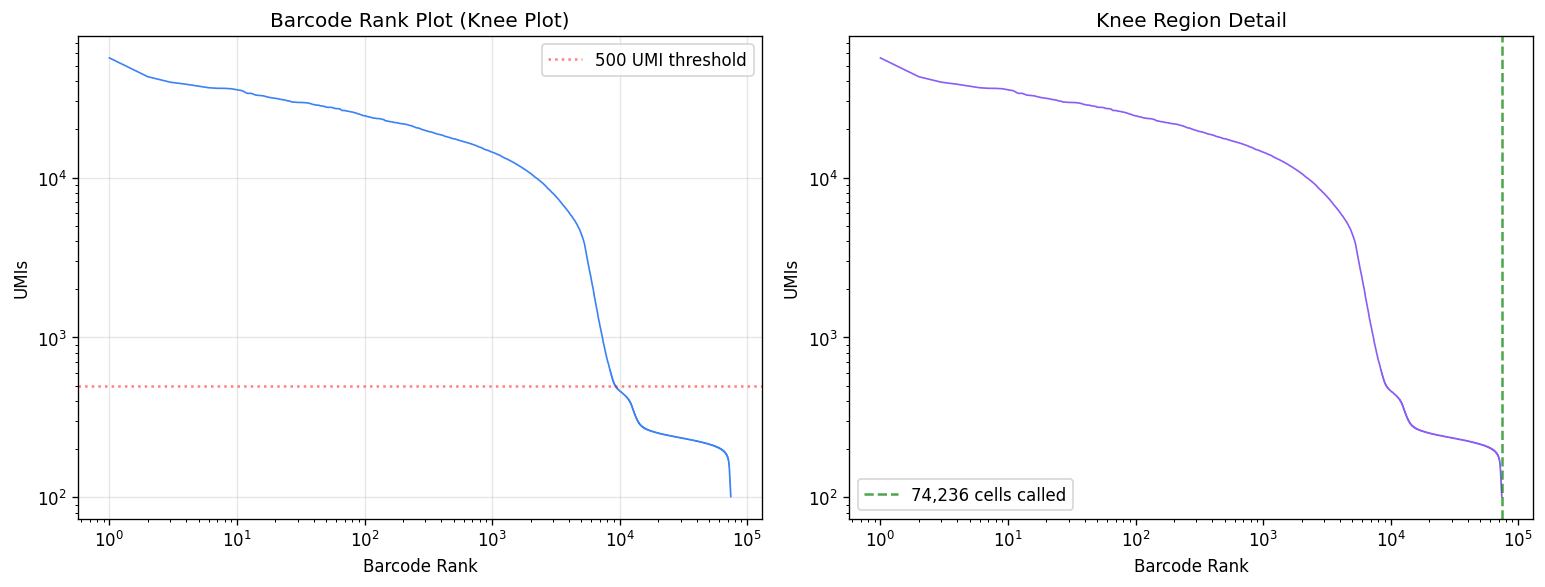

In [3]:
# Barcode rank plot (knee plot)
if umi_col:
    sorted_umis = calls[umi_col].sort_values(ascending=False).values
    
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # Log-log barcode rank
    ax = axes[0]
    ax.plot(range(1, len(sorted_umis) + 1), sorted_umis, linewidth=1, color='#3b82f6')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Barcode Rank')
    ax.set_ylabel('UMIs')
    ax.set_title('Barcode Rank Plot (Knee Plot)')
    ax.axhline(500, color='red', linestyle=':', alpha=0.5, label='500 UMI threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Zoomed in on the knee
    ax = axes[1]
    knee_region = sorted_umis[:min(len(sorted_umis), 200000)]
    ax.plot(range(1, len(knee_region) + 1), knee_region, linewidth=1, color='#8b5cf6')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Barcode Rank')
    ax.set_ylabel('UMIs')
    ax.set_title('Knee Region Detail')
    
    # Mark the called cell boundary
    if call_col:
        n_cells = (calls[call_col[0]] == True).sum() if calls[call_col[0]].dtype == bool else counts.iloc[0]
        ax.axvline(n_cells, color='green', linestyle='--', alpha=0.7, label=f'{n_cells:,} cells called')
        ax.legend()
    
    plt.tight_layout()
    plt.show()


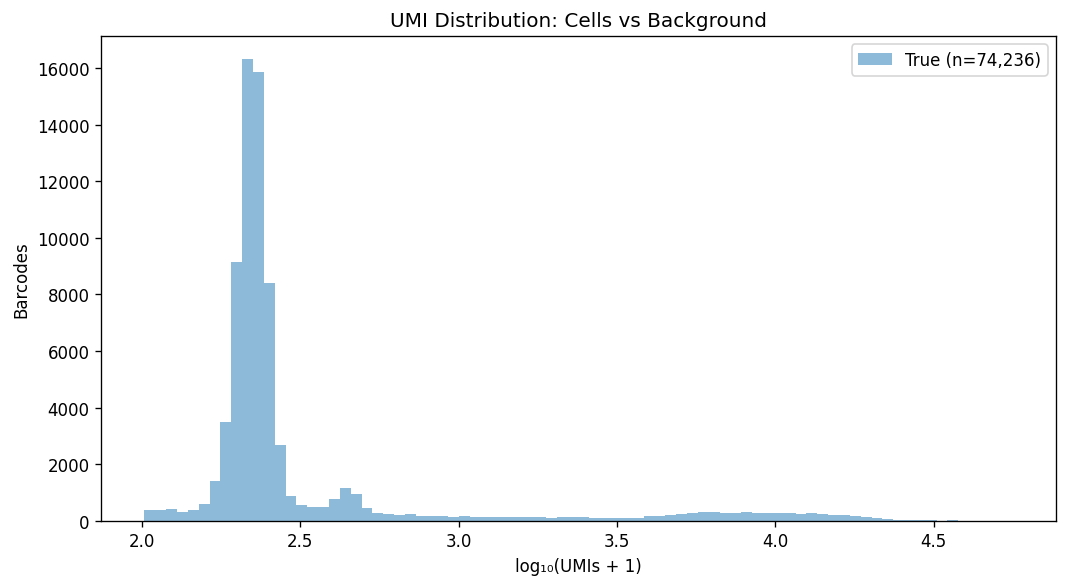

In [4]:
# UMI distribution of called cells vs background
if call_col and umi_col:
    fig, ax = plt.subplots(figsize=(9, 5))
    
    for cls in calls[call_col[0]].unique():
        subset = calls[calls[call_col[0]] == cls][umi_col]
        if len(subset) > 0:
            ax.hist(np.log10(subset + 1), bins=80, alpha=0.5, label=f'{cls} (n={len(subset):,})')
    
    ax.set_xlabel('log₁₀(UMIs + 1)')
    ax.set_ylabel('Barcodes')
    ax.set_title('UMI Distribution: Cells vs Background')
    ax.legend()
    plt.tight_layout()
    plt.show()
elif umi_col:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(np.log10(calls[umi_col] + 1), bins=80, color='#22c55e', edgecolor='white', linewidth=0.3)
    ax.set_xlabel('log₁₀(UMIs + 1)')
    ax.set_ylabel('Cells')
    ax.set_title(f'Called Cell UMI Distribution (n={len(calls):,})')
    plt.tight_layout()
    plt.show()


## Summary

| Metric | Value |
|--------|-------|
| Barcodes evaluated | ~750K |
| Cells called | ~74,000 |
| Method | Deviance-based (EmptyDrops-like) |
| Low-UMI rescue | Yes (statistical test) |

singlify's cell calling uses a deviance-based statistical test similar to EmptyDrops,
identifying real cells even at low UMI counts by testing gene expression profiles
against the ambient RNA background.